# Modelowanie układów przepływowych - Projekt pierwszy

pytanie - Jak zachowuje się fala, gdy na dnie znajduje się znaczne wgłębienie? Jaki jest przekrój wychylenia $\xi$ w projekcji na oś y po przejściu przez dołek?

### Pakiety Pythona

In [7]:
import sys
import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions

In [8]:
def intro():
    pyplot.figure(figsize=(14, 3))
    pyplot.axis('off')

    arrow_kwargs = {
        'length_includes_head': True,
        'head_width': 0.009,
        'head_length': 0.12
    }

    # batymetria (dołek)
    pyplot.fill_between(x, b, np.min(b)-1, color='brown', alpha=.4, label='$z=-b$')

    # fala
    pyplot.fill_between(x, h, b, color='blue', alpha=.15, label=r'$z=\zeta$')

    # strzałki
    ix = int(nx * 0.3)
    pyplot.arrow(x[ix], b[ix], 0, -b[ix], color='brown', **arrow_kwargs)
    pyplot.arrow(x[ix], 0, 0, b[ix], color='brown', **arrow_kwargs)
    pyplot.annotate("  $b$", xy=(x[ix], b[ix]+0.2), color='brown')

    ix = int(nx * 0.52)
    pyplot.arrow(x[ix], 0, 0, h[ix], color='blue', **arrow_kwargs)
    pyplot.arrow(x[ix], h[ix], 0, -h[ix], color='blue', **arrow_kwargs)
    pyplot.annotate("  $\\zeta$", xy=(x[ix], h[ix]-0.3), color='blue')

    ix = int(nx * 0.75)
    pyplot.arrow(x[ix], 0, 0, h[ix], color='black', **arrow_kwargs)
    pyplot.arrow(x[ix], 0, 0, b[ix], color='black', **arrow_kwargs)
    pyplot.annotate("  $h$", xy=(x[ix], b[ix]+0.4), color='black')
    pyplot.plot(x, np.full_like(x, 0), linestyle='--', color='black', label='$z=0$')
    pyplot.legend(loc="upper right")
    show_plot("bathymetry")

### Opis układu: symbole i równania

Na poniższym rysunku można podglądowo zobaczyć, jak będzie wyglądał układ w projekcji na oś y. Używanymi pojęciami są:
 - batymetria b(x) - kształt dna zadany w projekcie jest dany wzorem: $2 + A_b \cdot exp(-(\frac{(x-x_c)^2+(y-y_c)^2}{r}))$, gdzie $x_c$ oraz $y_c$ są współrzędnymi określającymi środek wgłębienia na dnie, natomiast r jest jego promieniem. W miejscu, gdzie nie ma dodatkowego wgłębienia, głębokość wody jest równa 2 metry. W pobliżu $x_c$ oraz $y_c$, dodatkowo zaimplementowano dołek w dnie o głębokości $A_b$.
 - wysokość fali $z = \zeta(x)$, dana wzorem: z(x)=$A\cdot exp(-(\frac{(x-x_0)^2}{t}))$ - analogicznym jak w przypadku batymetrii, lecz ograniczonym do jednego wymiaru - chcę sprawdzić, jak zachowa się fala prosta, a nie kulista gdy natrafi na wgłębienie. W przekroju jest ona gaussem z tego względu, że chciałabym uniknąć bardzo gwałtownych zmian jakichś wielkości ze względu na stabilność.
  - całkowita wysokość wody $h(x) = z(x) + b(x)$.

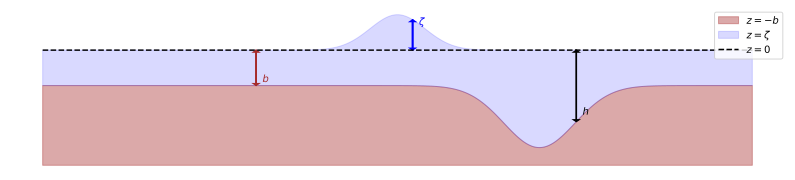

In [9]:
nx = 400
x = np.linspace(0, 1, nx)
y0 = 0.5
cx, cy = 0.7, 0.5
bump_amp = 3.5
radius_factor = 0.005
x0 = 0.5
wave_amplitude = 2
wave_thickness = 0.003
z = wave_amplitude * np.exp(-((x - x0)**2) / wave_thickness)
b = -(2 + bump_amp * np.exp(-((x - cx)**2) / radius_factor))
h = z

intro()

$$ \zeta(t; x,y) \rightarrow \text{wysokość swobodnej powierzchni względem geoidy (z=0)}$$
$$ b(x,y) \rightarrow \text{batymetria mierzona dodatnio w dół od geoidy}$$
$$ h(t; x,y) = \zeta + b \rightarrow \text{całkowita głębokość kolumny wody} $$
$$ \vec{u} = [u, v]$$
$$
\begin{cases}
  \partial_t h =\! -\nabla \cdot (\vec{u}h)\\
  \partial_t (hu) =\! -\nabla \cdot (\vec{u}hu) - gh\partial_x\zeta \\
  \partial_t (hv) =\! -\nabla \cdot (\vec{u}hv) - gh\partial_y\zeta
\end{cases}
$$
pierwsze równanie jest równaniem zachowania masy i mówi tyle, że woda nie może pojawiać się ani znikać znikąd - jej zmiany w ilości w każdej komórce są wywołane przepływem masy z innych komórek.
drugie oraz trzecie równanie określają zachowanie pędu - pęd jest przenoszony przez samego siebie. Po prawej stronie równania mamy siły wywołujące to przenoszenie, a więc grawitację oraz gradient zety w odpowiednim wymiarze x lub y. Oznacza on, że ruch jest spowodowany grawitacją, która ściąga wodę w niższe miejsca, oraz gradientem nachylenia powierzchni - ponieważ płaska powierzchnia nie ma nic ciekawego do przeniesienia.

### Solver

In [10]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, bathymetry: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }

        self.bathymetry = bathymetry
        self.t=0.0

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 #srednia dwoch sasiednich komorek w v
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        if (np.amax(np.abs(courant_number)) >= 1):
            print(np.amax(np.abs(courant_number)))
        assert np.amax(np.abs(courant_number)) <= 1

    def get_velocity_fields(self, eps: float=1e-8):
        """Zwraca (u, v) pola prędkości jako macierze o wymiarach h."""
        mask = self['h'] > eps
        u = np.zeros_like(self['h'])
        v = np.zeros_like(self['h'])
        # bez dzielenia przez 0
        np.divide(self['uh'], self['h'], where=mask, out=u)
        np.divide(self['vh'], self['h'], where=mask, out=v)
        return u, v

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        output['t'] = [] # czas -> bo dla danego dt/dxy jezeli chce zmienic gestosc siatki, to dxy maleje -> musze dt zmienic aby zachowac te sama liczbe couranta co podana w argumencie - do tego na czasie latwiej mi bedzie sledzic czas do pozniejszych porownan niz w liczbie iteracji
        nx, ny = self['h'].shape
        dx = 1.0 / (nx - 1)
        dy = 1.0 / (ny - 1)
        dt = min(dt_over_dxy[0] * dx, dt_over_dxy[1] * dy)

        T_output_step = outfreq * dt #zapisuje co konkretny interwal czasowy, a nie co x iteracji
        T_output_next = 0.0

        for it in range(nt + 1):
            if self.t >= T_output_next:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
                output['t'].append(self.t)
                T_output_next += T_output_step
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis]) #operators splitting
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            self.t += dt
        return output

In [11]:
def make_bathymetry_and_initial(
        nx, ny,
        bump_center,
        bump_amp,
        bump_radius_m,
        wave_amplitude,
        wave_position_factor,):

    X, Y = np.meshgrid(
        np.linspace(0, 1, nx),
        np.linspace(0, 1, ny),
        indexing='ij'
    )
    r2 = bump_radius_m**2
    bathymetry = 2 + bump_amp * np.exp(-((X - bump_center[0])**2 + (Y - bump_center[1])**2) / r2)

    h_initial = bathymetry.copy()
    wave_width_m = 0.05
    sigma = wave_width_m / 2.355
    x0 = wave_position_factor * 1.0
    x = np.linspace(0, 1, nx)
    gauss = wave_amplitude * np.exp(-((x - x0)**2) / (2 * sigma**2))
    h_initial += gauss[:, None]

    return h_initial, bathymetry

def run_sim(
        grid=(160,160),
        dt_over_dxy=(0.05, 0.05),
        nt=300,
        res_factor=1,
        dt_factor=1,
        lens_center=(0.7,0.5),
        lens_depth=3.5
    ):
    nx0, ny0 = grid
    nx = nx0 * res_factor
    ny = ny0 * res_factor

    dt_over_dxy_space = (dt_over_dxy[0] * res_factor, dt_over_dxy[1] * res_factor)
    dt_over_dxy_final = (dt_over_dxy_space[0] / dt_factor, dt_over_dxy_space[1] / dt_factor)

    nt_final = nt * dt_factor #potrzeba wiecej krokow jesli krok jest mniejszy, aby dojsc do tego samego momentu czasowego np 2s.

    h0, bath = make_bathymetry_and_initial(
        nx=nx,
        ny=ny,
        bump_center=lens_center,
        bump_amp=lens_depth,
        bump_radius_m=0.08,
        wave_amplitude=0.03,
        wave_position_factor=0.5,
    )
    out = ShallowWaterEquationsIntegrator(
        h_initial=h0,
        bathymetry=bath
    )(
        nt=nt_final,
        g=10,
        dt_over_dxy=dt_over_dxy_final,
        outfreq=3*dt_factor,
    )

    return out, bath


Wykonuję symulacje dla różnych parametrów N oraz dt/dx -> będę sprawdzać, jak symulacja przebiega przy zageszczeniu siatki dwa razy oraz pomniejszeniu kroku czasowego dwa razy.

In [12]:
out1, bath1 = run_sim(res_factor=1, dt_factor=1)
out2, bath2 = run_sim(res_factor=2, dt_factor=1)
out3, bath3 = run_sim(res_factor=1, dt_factor=2)
out4, bath4 = run_sim(res_factor=2, dt_factor=2)

In [13]:
def plot_velocity_frames(out, frames, step=3): #step równy 3 zeby rysowalo co 3 strzalke - ianczej pdf mi sie ladowal 15 minut
    fig, axes = pyplot.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    for idx, frame in enumerate(frames):
        ax = axes[idx]
        h  = out["h"][frame]
        uh = out["uh"][frame]
        vh = out["vh"][frame]
        u = uh / h
        v = vh / h
        nx, ny = u.shape
        X, Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')

        ax.quiver(
            X[::step, ::step],
            Y[::step, ::step],
            u[::step, ::step],
            v[::step, ::step],
            angles='xy', scale_units='xy')
        ax.set_aspect('equal')
        ax.set_title(f"velocity — frame {frame}")
        ax.set_xlabel(r'x/$\Delta$x')
        ax.set_ylabel(r'y/$\Delta$y')
        ax.grid(alpha=0.25)
    fig.suptitle("Velocity fields for selected frames", fontsize=16)
    pyplot.tight_layout()
    show_plot("velocity_frames_grid")


In [14]:
def plot_height_frames(out, bath, frames):
    fig, axes = pyplot.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for idx, frame in enumerate(frames):
        ax = axes[idx]
        h = out["h"][frame]
        zeta = (h - bath) * 100  # cm
        im = ax.imshow(zeta, origin='lower', cmap='viridis')
        ax.set_aspect("equal")
        ax.set_title(f"height ζ — frame {frame}")
        ax.set_xlabel(r'x/$\Delta$x')
        ax.set_ylabel(r'y/$\Delta$y')
        cbar = fig.colorbar(im, ax=ax, shrink=0.85)
        cbar.set_label("ζ [cm]")

    fig.suptitle("Height ζ = h − bath for selected frames", fontsize=16)
    pyplot.tight_layout()
    show_plot("height_frames_grid_individual_cbars")


In [15]:
def plot_cross_section_frames(out_list, bath_list, frames, pos, axis='x', Lx=1.0, Ly=1.0):
    colors     = ["#F29BC5", "#81A684", "#2C1320", "red"]
    linestyles = ["solid", (0, (5, 5)), (0, (1, 5)), "dashed"]
    labels     = ["ref", "2× grid", "dt/2", "2× grid and dt/2"]

    fig, axes = pyplot.subplots(2, 2, figsize=(10, 8))
    axes_flat = axes.ravel()
    used_axes = axes_flat[:len(frames)]

    for ax, frame in zip(used_axes, frames):
        for k, out in enumerate(out_list):
            h = out['h'][frame]
            zeta = (h - bath_list[k]) * 100.0   # cm
            nx, ny = zeta.shape
            x = np.linspace(0, Lx, nx)
            y = np.linspace(0, Ly, ny)
            step_x = max(1, nx // 300)
            step_y = max(1, ny // 300)

            if axis == 'x':
                j = int((pos / Ly) * (ny - 1))
                j = np.clip(j, 0, ny - 1)
                ax.plot(x[::step_x],zeta[:, j][::step_x],label=labels[k],color=colors[k],linestyle=linestyles[k],lw=2.0, alpha=0.85)
                ax.set_xlabel("x [m]")
            elif axis == 'y':
                i = int((pos / Lx) * (nx - 1))
                i = np.clip(i, 0, nx - 1)
                ax.plot(y[::step_y],zeta[i, :][::step_y],label=labels[k],color=colors[k],linestyle=linestyles[k],lw=2.0,alpha=0.85)
                ax.set_xlabel("y [m]")

        ax.set_title(f"frame {frame}")
        ax.set_ylabel("ζ [cm]")
        ax.grid(alpha=0.3)

    for ax in axes_flat[len(frames):]:
        ax.set_visible(False)

    axes_flat[0].legend()
    fig.suptitle(f"Cross-section ζ({axis}) at pos={pos:.2f} m", fontsize=16)
    pyplot.tight_layout()
    show_plot(f"cross_section_multi_axis={axis}")


In [16]:
def plot_bathymetries(bath_list, Lx=1.0, Ly=1.0):
    n = len(bath_list)
    fig, axes = pyplot.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]
    for k, (ax, bath) in enumerate(zip(axes, bath_list)):
        nx, ny = bath.shape
        x = np.linspace(0, Lx, nx)
        y = np.linspace(0, Ly, ny)
        im = ax.imshow(bath.T,extent=[0, Lx, 0, Ly],origin='lower',aspect='equal',cmap="viridis")
        ax.set_title(f"Bathymetry #{k}  ({nx}×{ny})")
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        fig.colorbar(im, ax=ax, shrink=0.8, label="depth [m]")

    fig.suptitle("Bathymetries for all resolutions", fontsize=16)
    pyplot.tight_layout()
    show_plot("bathymetries")

In [17]:
def show_simulation(out_list, bath_list, frames, plot, x_section_pos=0.5, y_section_pos=0.9):
    if plot == 'velocity':
        plot_velocity_frames(out_list[0], frames)
    if plot == 'height':
        plot_height_frames(out_list[0],bath_list[0], frames)
    if plot == 'cross-section':
        plot_cross_section_frames(out_list, bath_list, frames,pos=x_section_pos, axis='x')
        plot_cross_section_frames(out_list, bath_list, frames, pos=y_section_pos, axis='y')
    if plot == 'bathymetry':
        plot_bathymetries(bath_list)

### Wykresy oraz analiza

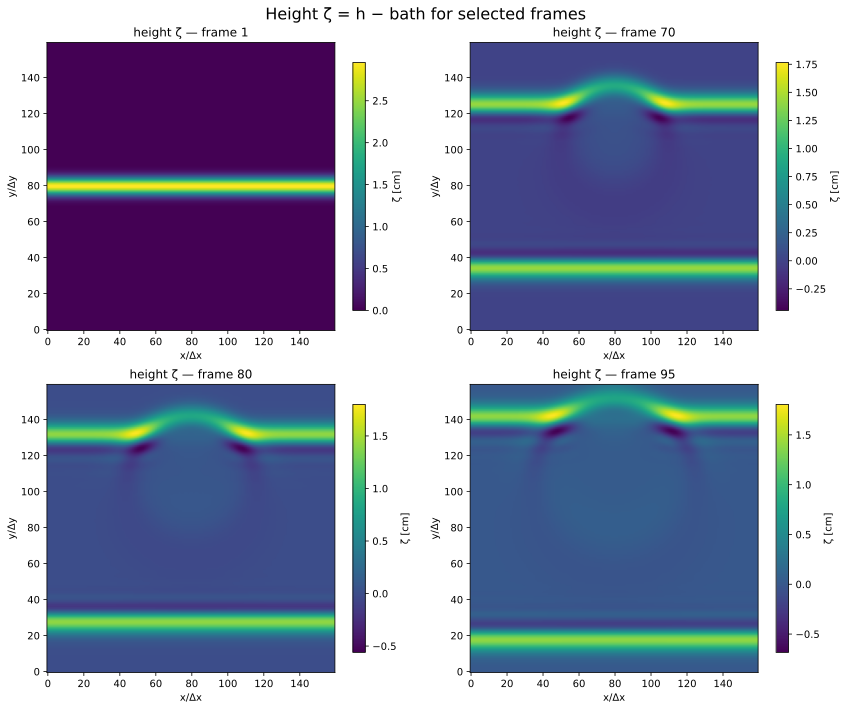

In [18]:
frames=[1,70,80,95]
out_list=[out1, out2,out3, out4]
bath_list=[bath1, bath2,bath3, bath4]
show_simulation(
    out_list=out_list,
    bath_list=bath_list,
    frames=frames,
    plot='height',
    x_section_pos=0.5,
    y_section_pos=0.9
)

Powyżej przedstawiono, jak wygląda mapa $\zeta$ w funkcji położenia w osi x oraz y. Ze względu na to, że początkowa fala została zainicjowana na samym środku, a dołek jest przesunięty względem centrum na x=0.9, to możemy zaobserwować różnice między rozchodzeniem się fali nad dołkiem oraz bez efektów z dnem. Przez to, że dodano dołek, który powoduje zwiększenie głębokości, można zaobserwować zwiększenie się prędkości fali bezpośrednio nad dołkiem. Widać to jako przesunięcie się czoła fali na przód. Wynika to z zależności $c=\sqrt{gh}$, gdzie c jest prędkością fali, h - wysokością słupa wody, a g - przyśpieszeniem grawitacyjnym.

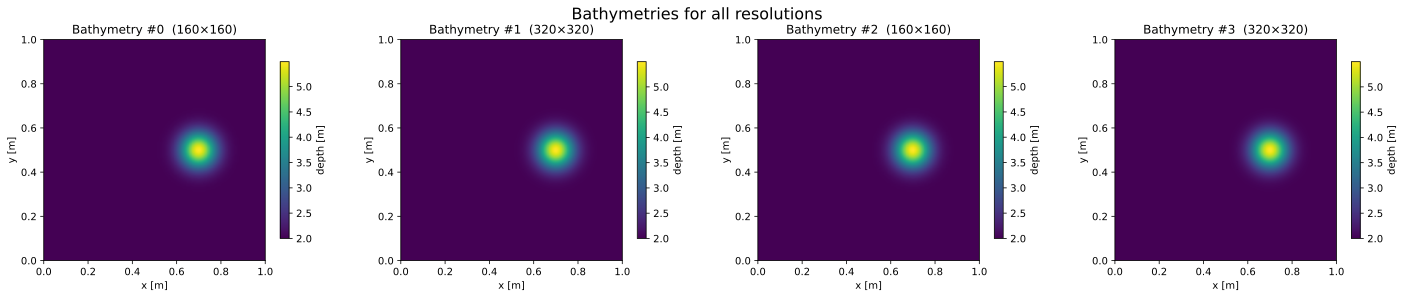

In [19]:
show_simulation(out_list, bath_list, frames=frames, plot='bathymetry', x_section_pos=0.5, y_section_pos=0.9)

In [20]:
show_simulation(
    out_list=out_list,
    bath_list=bath_list,
    frames=frames,
    plot='velocity',
    x_section_pos=0.5,
    y_section_pos=0.9
)

Powyżej przedstawiono pole wektorowe prędkości rozchodzących się fal.

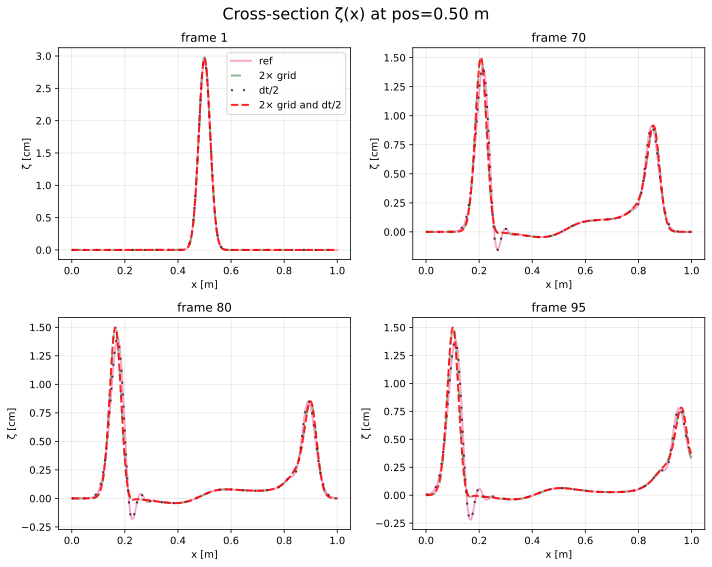

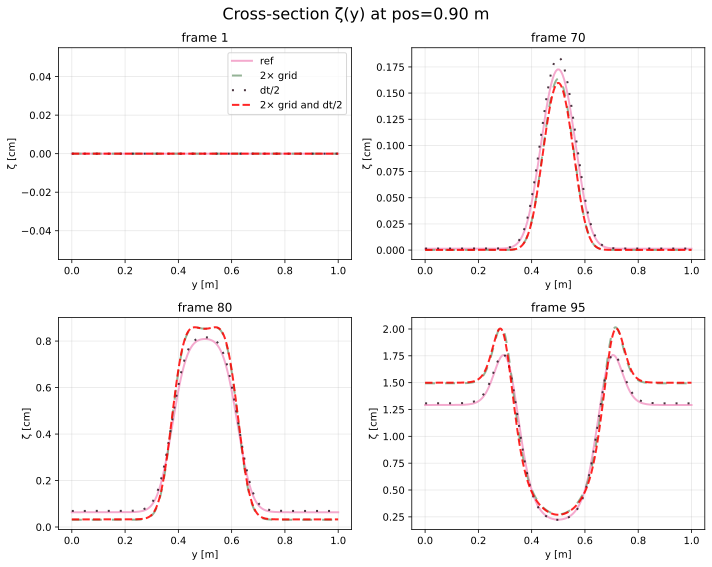

In [21]:
frames=[1,70,80,95]
show_simulation(
    out_list=out_list,
    bath_list=bath_list,
    frames=frames,
    plot='cross-section',
    x_section_pos=0.5,
    y_section_pos=0.9
)

Powyżej przedstawiono wychylenia $\zeta$ na osie x oraz y w najciekawszych momentach czasowych, wraz z porównaniem, jak zmieniają się wyniki przy większej gęstości siatki przestrzennej oraz mniejszym kroku dt/dx. W przekroju na oś x wybrano y=50, natomiast dla przekroju dla y - obrano x=0.9 tak, aby pokazać, jak zmienia się ten przekrój fali po przejściu przez dołek. Na wykresach względem osi x zauważamy, jak czoła fali poruszają się w stronę malejących oraz rosnących x. Wraz z upływem czasu, można zauważyć, że wysokość fali, która pokonuje dołek, jest coraz mniejsza i nieco rozpływa się u dołu względem drugiej, niezmienionej. Dzieje się tak, ponieważ fala ulega rozmyciu/rozproszeniu podczas przechodzenia przez dołek. W momencie, gdy część fali wchodzi w obszar dołka, a druga nie, następuje przyśpieszenie jakiejś części fali, gdy poprzednia nadal nie jest pod wpływem dołka. Fala już "oddziałująca" z dołkiem ma większą prędkość ze względu na głębsze dno, zgodnie ze wzorem $c=\sqrt{hg}$, a więc lekko ucieka reszcie fali. Z zasady zachowania masy wynika więc, że fala podczas rozmycia się w przestrzeni, będzie musiała zmniejszyć swoją amplitudę. Zmiany ze względu na mniejszy krok czasowy czy przestrzenny nie zmieniły jakościowo zachowania się fali. Widać lekkie różnice w wysokościach amplitud, które może wynikać z niedokładnego dopasowania czasowego dla wybranych klatek.

Z kolei w przypadku zależności $\zeta(y)$, możemy zaobserwować stopniowe pojawianie się czoła fali dla przekroju x=0.9. Dla klatki 70 fala zaczyna się pojawiać, i ma małą amplitudę ok. 0.175 cm. Dla tak małych wartości widać również lekkie rozbieżności między zastosowanymi parametrami symulacji - dla zastosowanego mniejszego kroku dt/dx. Dla klatki 80 fala staje się jeszcze większa i osiąga amplitudę 0.8. W klatce 95 obserwujemy, że powstały maksima $\zeta$ dla $y/\Delta y$ =0.3 oraz 0.7 metra. Dzieje się tak, ponieważ podczas rozproszenia się fali na dołku, nie rozprasza się ona jedynie w osi x, a również nieco w osi y. Fala rozproszona ulega nakładaniu się z falą nierozproszoną, powodując lokalne zwiększenie się amplitudy, która osiągnęła teraz wartość większą, niż początkowo powstałe dwie fale (do około 2 cm).


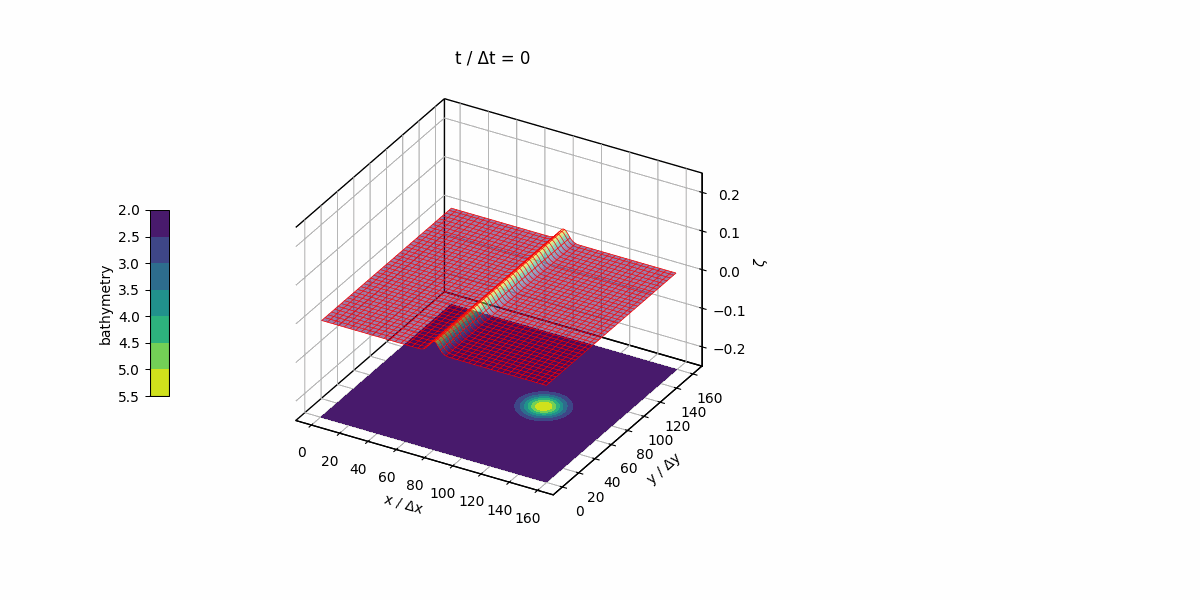

HTML(value="<a href='.\\tmponozcn7i.gif' target='_blank'>.\\tmponozcn7i.gif</a><br>")

In [23]:
# def plot(frame, *, zlim=(-.25, 0.25)):
#     psi = out1['h'][frame]-bath1
#     xi, yi = np.indices(psi.shape)
#     fig, ax = pyplot.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 6))
#     ax.plot_surface(xi+.5, yi+.5, psi, cmap="viridis", rstride=1, cstride=1,
#                 alpha=0.6, linewidth=0)
#     ax.plot_wireframe(xi+.5, yi+.5, psi, color='red', linewidth=.5)
#     ax.set(zlim=zlim, proj_type='ortho', title=f"t / Δt = {frame}", zlabel=r"$\zeta$")
#     for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
#         axis.pane.fill = False
#         axis.pane.set_edgecolor('black')
#         axis.pane.set_alpha(1)
#     for axis in ('x', 'y'):
#         getattr(ax, f'set_{axis}label')(f"{axis} / Δ{axis}")
#     pyplot.colorbar(
#         ax.contourf(xi+.5, yi+.5, bath1, zdir='z', offset=zlim[0]),
#         pad=.1, aspect=10, fraction=.02, label='bathymetry', location='left'
#     ).ax.invert_yaxis()
#     return fig
# show_anim(plot, range(len(out1['h'])))